<a href="https://colab.research.google.com/github/IrumShehryar/ML-NLP-Coursework/blob/main/nlp/07-BiLSTM/Project_03_DualBidirectionalLSTM_MNIST_TFllow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Flatten, Bidirectional, GlobalMaxPooling1D, Lambda, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import keras.backend as K # In keras backend refers to the computational engine executing operations and computations in deep learning
                          # models. The backend configuration determines which computational engine runs numeric expressions.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
from sklearn.model_selection import train_test_split

# Load in the data

In [2]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), _ = mnist.load_data()
print("x_train.shape:", x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train.shape: (60000, 28, 28)


In [3]:
x_train.dtype

dtype('uint8')

# Extract first 10000 samples

In [4]:
X  = x_train[0:10000, :]

In [5]:
X.shape # N x T x D

(10000, 28, 28)

In [6]:
y = y_train[0:10000]

In [7]:
y.shape

(10000,)

# Perform Train test split

In [8]:
train_data, test_data, train_labels, test_labels = train_test_split(X, y, test_size = 0.1)

In [9]:
train_data[0].shape  # shape of the first sample of train_data

(28, 28)

# Create the Model

In [15]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Flatten, Bidirectional, GlobalMaxPooling1D, Lambda, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import keras.backend as K # In keras backend refers to the computational engine executing operations and computations in deep learning
                          # models. The backend configuration determines which computational engine runs numeric expressions.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
from sklearn.model_selection import train_test_split

# input is an image of size 28x28

input = Input(shape=(train_data[0].shape))

# First bidirectional LSTM ( up-down )

Bi_LSTM_01 = Bidirectional(LSTM(128, return_sequences=True)) # return_sequences=True so that we get all the hidden states
X1 = Bi_LSTM_01(input) # output is N x D x 2H
X1 = GlobalMaxPooling1D()(X1) # output is N x 2H

# Second bidirectional LSTM ( left-right )

Bi_LSTM_02 = Bidirectional(LSTM(128, return_sequences=True))

# We need to create permute layer to switch the dimensions of T x D

permuteLayer = Lambda(lambda t: tf.transpose(t, perm=[0, 2, 1]), output_shape=(28, 28))

X2 = permuteLayer(input)
X2 = Bi_LSTM_02(X2) # output is N x D x 2H
X2 = GlobalMaxPooling1D()(X2) # output is N x 2H

# Concatenate both flatten outputs

concatenationLayer = Concatenate(axis=1)
X = concatenationLayer([X1, X2]) # output is N x 4H

# final dense layer
output = Dense(10, activation='softmax')(X) # N x C

model = Model(inputs=input, outputs=output)

In [12]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 28, 28)    │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 28, 256)   │    160,768 │ input_layer_1[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 28, 256)   │    160,768 │ lambda_1[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ bidirectional_2[… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ bidirectional_3[… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │      5,130 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 326,666 (1.25 MB)

 Trainable params: 326,666 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

# Compile the Model

In [13]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the Model

In [17]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist = model.fit(train_data, train_labels, validation_data=(test_data, test_labels), epochs = 50)

Epoch 1/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 47s 147ms/step - accuracy: 0.8300 - loss: 0.6559 - val_accuracy: 0.9330 - val_loss: 0.2708
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 75s 121ms/step - accuracy: 0.9528 - loss: 0.1857 - val_accuracy: 0.9490 - val_loss: 0.1812
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 43s 128ms/step - accuracy: 0.9667 - loss: 0.1264 - val_accuracy: 0.9540 - val_loss: 0.1569
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 34s 120ms/step - accuracy: 0.9786 - loss: 0.0844 - val_accuracy: 0.9620 - val_loss: 0.1322
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 41s 121ms/step - accuracy: 0.9839 - loss: 0.0656 - val_accuracy: 0.9600 - val_loss: 0.1258
Epoch 6/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 43s 126ms/step - accuracy: 0.9899 - loss: 0.0470 - val_accuracy: 0.9570 - val_loss: 0.1313
Epoch 7/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 35s 122ms/step - accuracy: 0.9898 - loss: 0.0446 - val_accuracy: 0.9580 - val_loss: 0.1192
Epoch 8/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 36s 126ms/step - accuracy: 0.9894 - loss: 0

# Visualize the Model Performance

In [18]:
trainAcc = [100 * x for x in hist.history['accuracy']]
testAcc = [100 * x for x in hist.history['val_accuracy']]

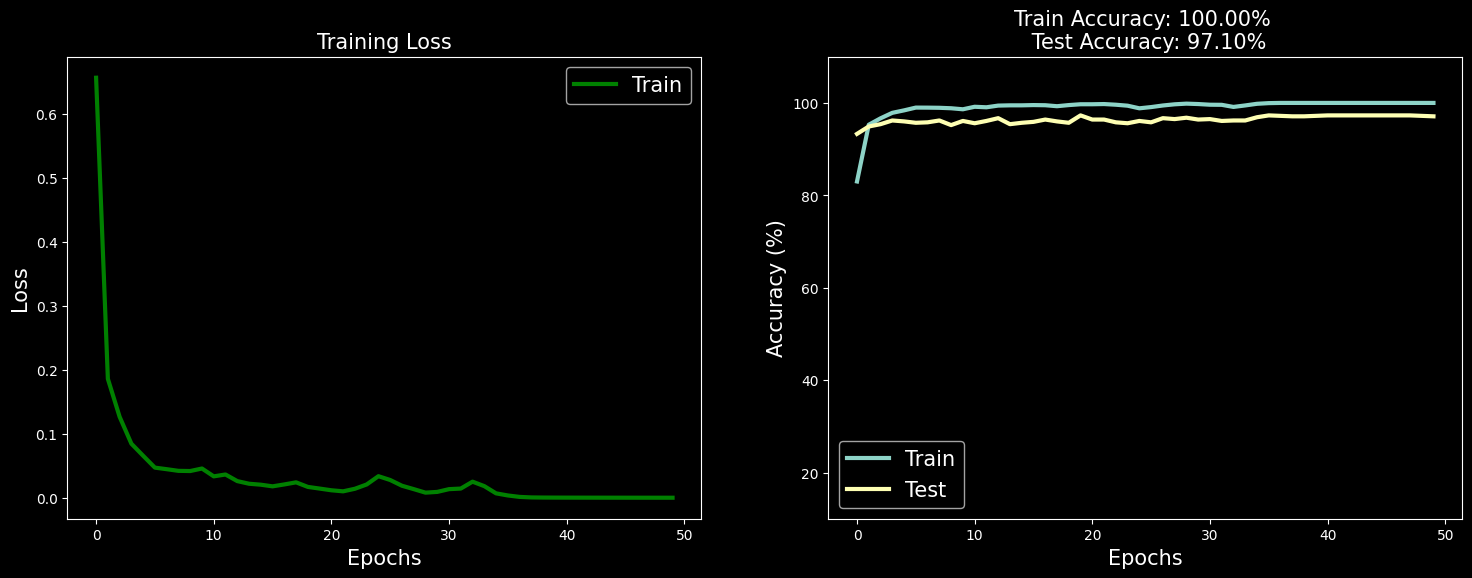

In [19]:
fig,ax = plt.subplots(1,2,figsize=(18,6))

ax[0].plot(hist.history['loss'], 'g', lw = 3, label = 'Train')
ax[0].set_xlabel('Epochs', fontsize = 15)
ax[0].set_ylabel('Loss', fontsize = 15)
ax[0].legend(fontsize = 15)
ax[0].set_title('Training Loss', fontsize = 15)


ax[1].plot(trainAcc, label ='Train', lw = 3)
ax[1].plot(testAcc, label ='Test', lw = 3)
ax[1].set_xlabel('Epochs', fontsize = 15)
ax[1].set_ylabel('Accuracy (%)', fontsize = 15)
ax[1].set_ylim([10,110])
ax[1].set_title(f'Train Accuracy: {trainAcc[-1]:.2f}% \n Test Accuracy: {testAcc[-1]:.2f}%', fontsize = 15)
ax[1].legend(fontsize = 15)

plt.show()

# Creating Function Using Lambda

In [ ]:
square = lambda num: num ** 2   # we use lamda when we need quick results and we dont want to save it for longer time

In [ ]:
square(6)

# Understanding PermuteLayer

In [ ]:
x = np.random.rand(32, 28, 10)

In [ ]:
permuteLayer = Lambda(lambda t: K.permute_dimensions(t, pattern=(0, 2, 1)))

In [ ]:
output = permuteLayer(x)

In [ ]:
output.shape